In [55]:
import jax.numpy as jnp 
import matplotlib.pyplot as plt 

from jax import vmap
from jax_md.energy import soft_sphere
from jax_md import util

f32 = util.f32

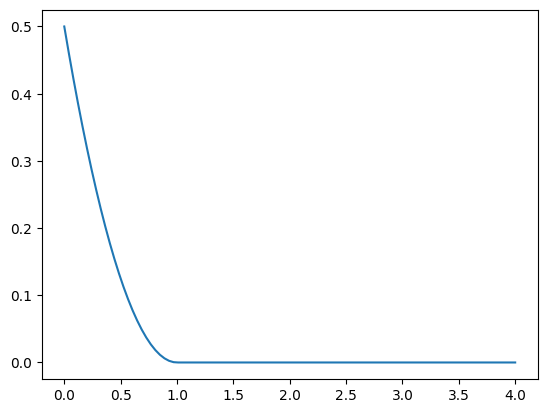

In [56]:
dr = jnp.linspace(0, 4., num=100)

plt.plot(dr, soft_sphere(dr))
plt.show()


In [57]:
# Default values of soft_sphere function
sigma = 1.
epsilon = 1.
alpha = 2.

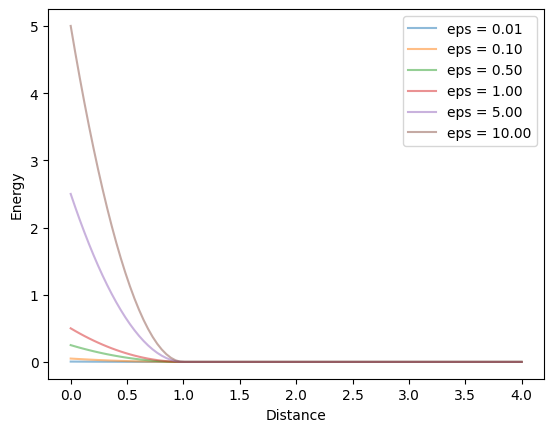

In [59]:
# Plot effect of epsilon (fixed alpha) 
epsilons = jnp.array([0.01, 0.1, 0.5, 1., 5., 10])
energies_fn = vmap(soft_sphere, (None, None, 0, None))
energies = energies_fn(dr, sigma, epsilons, f32(alpha))

for eps, e in zip(epsilons, energies):
    plt.plot(dr, e, label=f"eps = {eps:.2f}", alpha=0.5)


plt.legend()
plt.ylabel('Energy')
plt.xlabel('Distance')
plt.show()

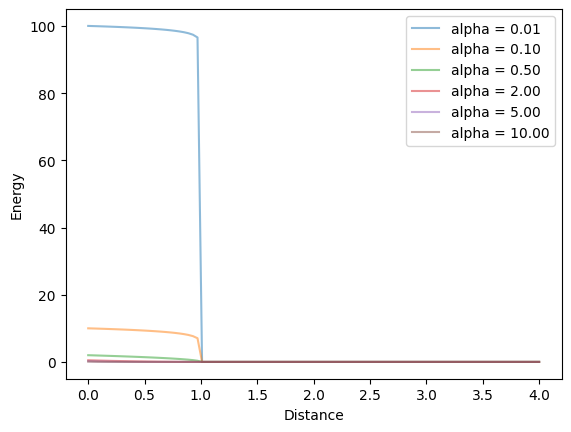

In [60]:
# Plot effect of alpha (fixed epsilon) 
alphas = jnp.array([0.01, 0.1, 0.5, 2., 5., 10])
energies_fn = vmap(soft_sphere, (None, None, None, 0))
energies = energies_fn(dr, sigma, epsilon, alphas)

for alpha, e in zip(alphas, energies):
    plt.plot(dr, e, label=f"alpha = {alpha:.2f}", alpha=0.5)

plt.legend()
plt.legend()
plt.ylabel('Energy')
plt.xlabel('Distance')
plt.show()

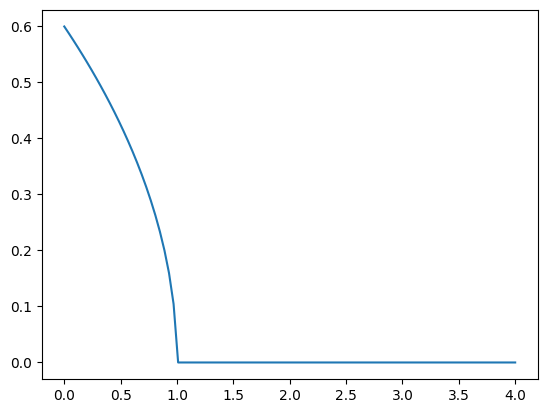

In [61]:
# Try custom parameters 
sigma = 1.
epsilon = 0.3 
alpha = 0.5 

e = soft_sphere(dr, sigma=sigma, epsilon=epsilon, alpha=f32(alpha))

plt.plot(dr, e)
plt.show()

In [2]:
# TODO : Understand how to give different alphas and epsilons to two particles interacting 